In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/audio"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
print(os.listdir(DATASET_PATH))


['english', 'bangla']


In [3]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE


In [4]:
def extract_mfcc(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)


In [5]:
X = []
y = []

languages = {'bangla': 0, 'english': 1}

for language, label in languages.items():
    language_path = os.path.join(DATASET_PATH, language)

    for root, dirs, files in os.walk(language_path):
        for file in files:
            if file.lower().endswith((".mp3", ".wav")):
                file_path = os.path.join(root, file)
                try:
                    features = extract_mfcc(file_path)
                    X.append(features)
                    y.append(label)
                except Exception as e:
                    print("Error loading:", file_path)

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape[0])
print("Feature dimension:", X.shape[1])


Total samples: 332
Feature dimension: 13


In [6]:
#normalize feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [36]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU()
        )
        # Adjusted latent dimension to 16
        self.mu = nn.Linear(64, 16)
        self.logvar = nn.Linear(64, 16)

        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 13)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [69]:
BETA = 0.05  # try 0.1–0.5

def vae_loss(recon_x, x, mu, logvar):
    recon = F.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + BETA * kl


In [70]:
import torch.nn.functional as F
import torch.utils.data as data

# Prepare data
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = data.TensorDataset(X_tensor)
batch_size = 10
loader = data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE().to(device) # Re-initialize the model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 100

PRINT_EVERY = 10

for epoch in range(EPOCHS):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % PRINT_EVERY == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(dataset):.4f}")

Epoch 1/100, Loss: 13.2513
Epoch 10/100, Loss: 4.5774
Epoch 20/100, Loss: 2.9917
Epoch 30/100, Loss: 2.4140
Epoch 40/100, Loss: 2.0674
Epoch 50/100, Loss: 1.9118
Epoch 60/100, Loss: 1.8470
Epoch 70/100, Loss: 1.7361
Epoch 80/100, Loss: 1.6772
Epoch 90/100, Loss: 1.6309
Epoch 100/100, Loss: 1.6058


In [71]:
model.eval()
latent_features = []

with torch.no_grad():
    for batch in loader:
        x = batch[0].to(device)
        mu, _ = model.encode(x)
        latent_features.append(mu.cpu().numpy())

latent_features = np.vstack(latent_features)
print("Latent shape:", latent_features.shape)


Latent shape: (332, 16)


In [72]:
kmeans_vae = KMeans(n_clusters=2, random_state=42)
vae_clusters = kmeans_vae.fit_predict(latent_features)


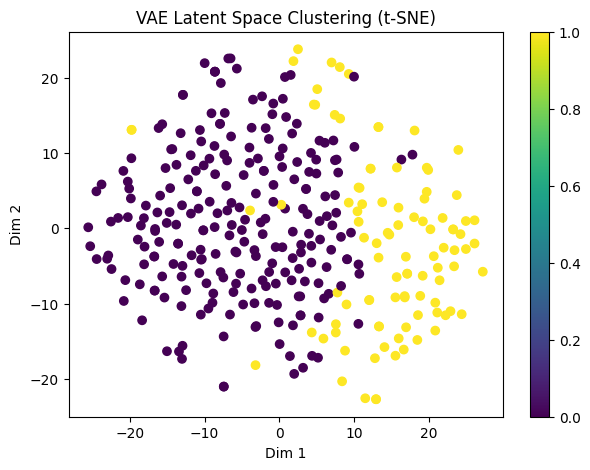

In [73]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vae_tsne = tsne.fit_transform(latent_features)

plt.figure(figsize=(7,5))
plt.scatter(vae_tsne[:,0], vae_tsne[:,1], c=vae_clusters)
plt.title("VAE Latent Space Clustering (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar()
plt.show()


In [74]:
pca = PCA(n_components=13)
pca_features = pca.fit_transform(X)

kmeans_pca = KMeans(n_clusters=2, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_features)

In [75]:
vae_sil = silhouette_score(latent_features, vae_clusters)
vae_ch = calinski_harabasz_score(latent_features, vae_clusters)

pca_sil = silhouette_score(pca_features, pca_clusters)
pca_ch = calinski_harabasz_score(pca_features, pca_clusters)

print("===== FINAL RESULTS =====")
print(f"VAE + KMeans  → Silhouette: {vae_sil:.4f}, CH Index: {vae_ch:.2f}")
print(f"PCA + KMeans  → Silhouette: {pca_sil:.4f}, CH Index: {pca_ch:.2f}")


===== FINAL RESULTS =====
VAE + KMeans  → Silhouette: 0.1628, CH Index: 44.85
PCA + KMeans  → Silhouette: 0.4261, CH Index: 371.18
